<div align="center">

# Load and Plot EEG Files

</div>

> This file serves the purpose of checking how to load and plot the EEG files

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

## 1. Simple function to load and plot

In [2]:
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]
        intervals = f["seizure_intervals"][:] if "seizure_intervals" in f else np.array([])
        
    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]
    return signals, fs, ch_names, intervals

In [3]:
path = "../Dataset_hdf5/chb10/chb10_12.h5"
signals, fs, ch_names, intervals = load_h5(
    "../Dataset_hdf5/chb10/chb10_12.h5"
)

print(signals.shape)
print(fs)
print(ch_names)
print(intervals)

(23, 1843200)
256.0
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
[[1616128 1625088]]


# 2. EEG with all channels

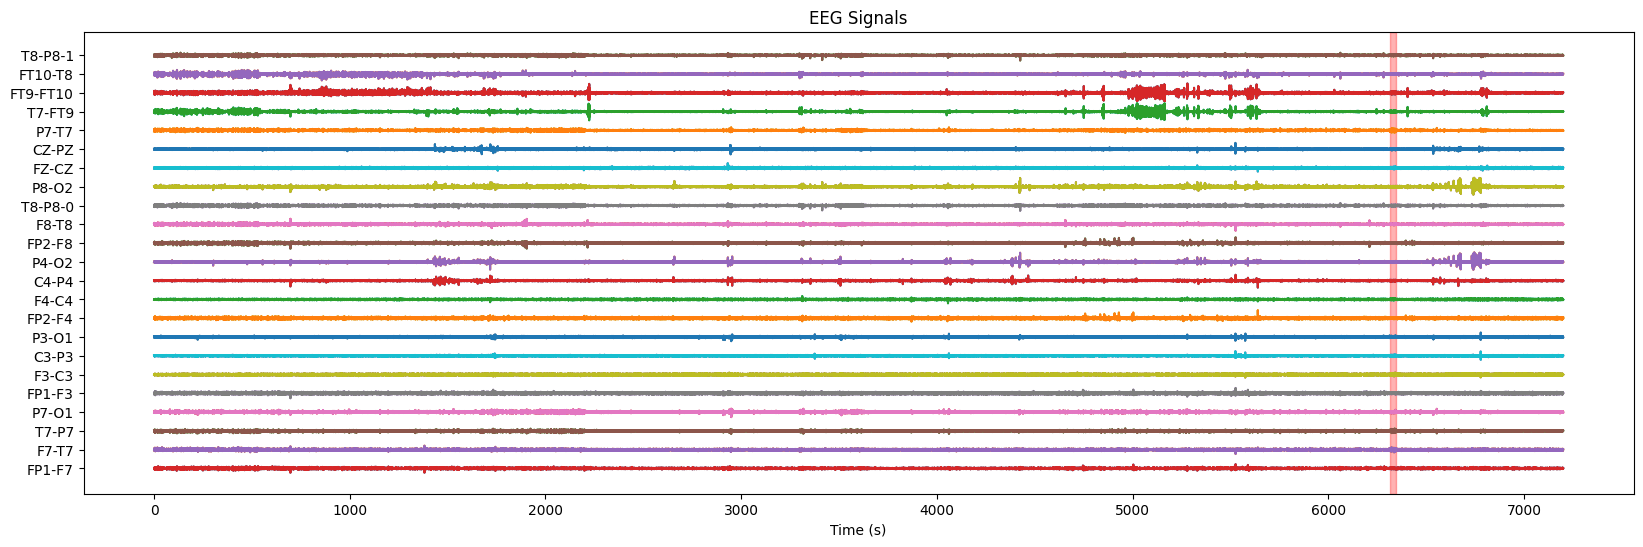

In [4]:
plt.figure(figsize=(20, 6))

n_channels = signals.shape[0]
t = np.arange(signals.shape[1]) / fs

offset = 0
spacing = np.max(np.abs(signals)) * 2

for i in range(n_channels):
    plt.plot(t, signals[i] + offset, label=ch_names[i])
    offset += spacing

# --- FIXED seizure highlighting ---
intervals = np.array(intervals)

if intervals.size > 0:
    if intervals.ndim == 1:
        intervals = intervals.reshape(1, -1)

    for start, end in intervals:
        plt.axvspan(start / fs, end / fs, color='red', alpha=0.3)

yticks = []
ylabels = []

offset = 0
for i in range(n_channels):
    plt.plot(t, signals[i] + offset)
    yticks.append(offset)
    ylabels.append(ch_names[i])
    offset += spacing

plt.xlabel("Time (s)")
plt.title("EEG Signals")
plt.yticks(yticks, ylabels)
plt.show()

# 3. Function for plotting

In [5]:

def plot_eeg(
    signals,
    fs,
    ch_names=None,
    intervals=None,
    channels=None,        # list of indices OR names
    t_start=None,         # in seconds
    t_end=None,           # in seconds
    figsize=(15, 8),
    color_mode=None,
    seizure_color= '#bfd630',
    seizure_alpha = 0.4,
    title = 'EEG Signals',
    linewidth=1
):
    """
    Flexible EEG plotter.

    Parameters:
    - signals: (n_channels, n_samples)
    - fs: sampling frequency
    - ch_names: list of channel names
    - intervals: seizure intervals (samples or seconds)
    - channels: list of channel indices OR names to plot
    - t_start, t_end: time window in seconds
    - figsize: figure size
    """

    # --- Channel selection ---
    if channels is not None:
        if isinstance(channels[0], str):
            idx = [ch_names.index(ch) for ch in channels]
        else:
            idx = channels
        signals = signals[idx]
        if ch_names is not None:
            ch_names = [ch_names[i] for i in idx]

    n_channels, n_samples = signals.shape

    # --- Time window selection ---
    if t_start is None:
        t_start = 0
    if t_end is None:
        t_end = n_samples / fs

    start_sample = int(t_start * fs)
    end_sample = int(t_end * fs)

    signals = signals[:, start_sample:end_sample]
    t = np.arange(start_sample, end_sample) / fs



    # Color
    # --- COLOR SETUP ---
    if color_mode == "tab10":
        colors = plt.cm.tab10(np.linspace(0, 1, n_channels))
    elif color_mode == "viridis":
        colors = plt.cm.viridis(np.linspace(0, 1, n_channels))
    else:
        colors = ["gray"] * n_channels

        
    # --- Plot ---
    plt.figure(figsize=figsize)

    spacing = np.max(np.abs(signals)) * 2
    offset = 0

    yticks = []
    ylabels = []

    for i in range(n_channels):
        plt.plot(t, signals[i] + offset, color=colors[i], linewidth=linewidth)
        yticks.append(offset)
        if ch_names is not None:
            ylabels.append(ch_names[i])
        else:
            ylabels.append(f"Ch {i}")
        offset += spacing
    
    plt.yticks(yticks, ylabels)


    # --- Seizure highlighting (FIXED) ---
    if intervals is not None:
        intervals = np.array(intervals)

        if intervals.size > 0:
            if intervals.ndim == 1:
                intervals = intervals.reshape(1, -1)

            for start, end in intervals:

                # --- ALWAYS convert to seconds ---
                start = start / fs
                end = end / fs

                # --- check overlap with window ---
                if end >= t_start and start <= t_end:

                    # --- clip to visible region ---
                    start_clip = max(start, t_start)
                    end_clip = min(end, t_end)

                    plt.axvspan(start_clip, end_clip, color=seizure_color, alpha=seizure_alpha)

    plt.xlabel("Time (s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 3.1 Change Figure Size

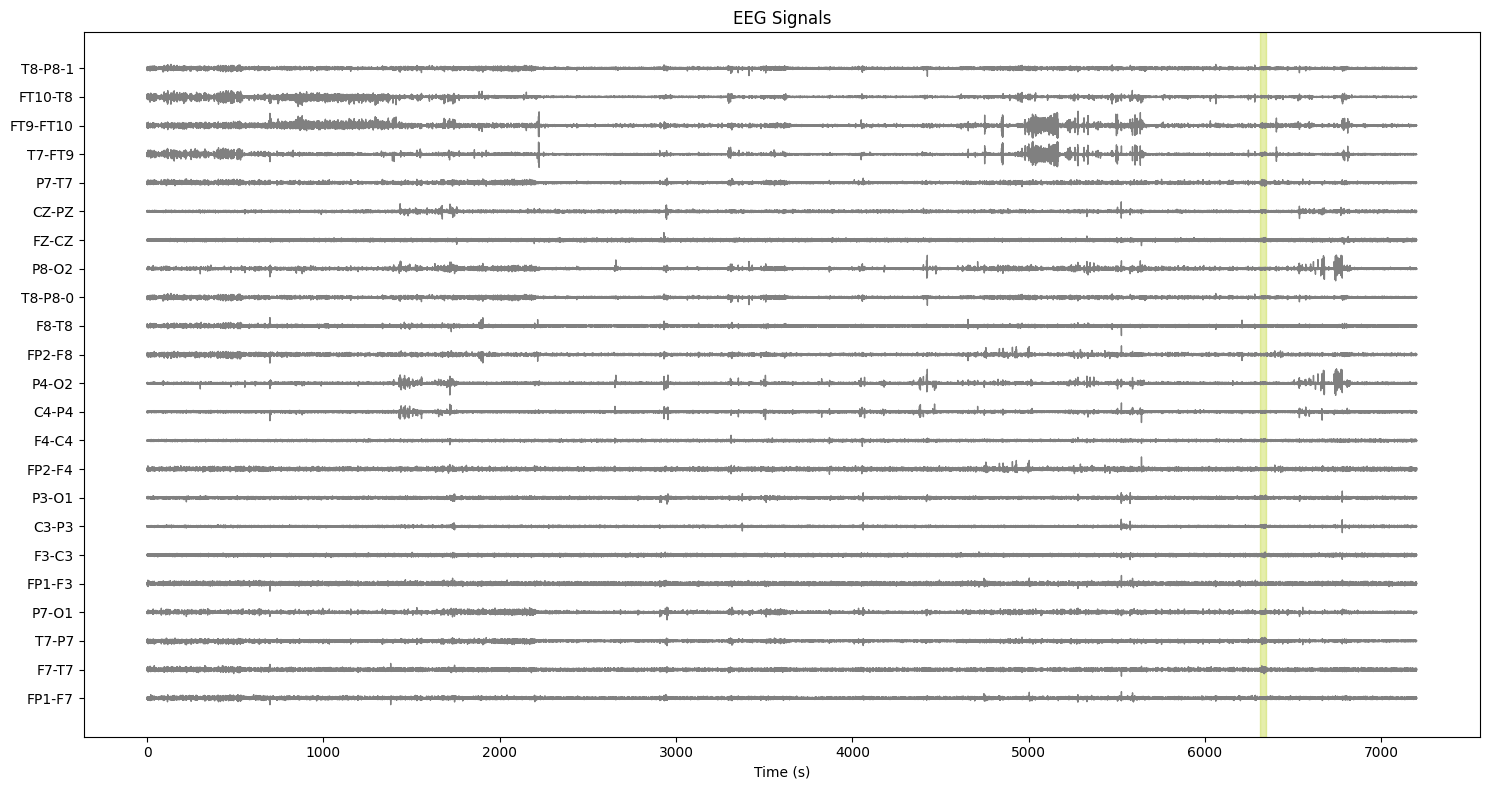

In [ ]:
plot_eeg(signals, fs, ch_names, intervals=intervals,figsize=(15, 8))

## 3.2 Plot Specific Channels

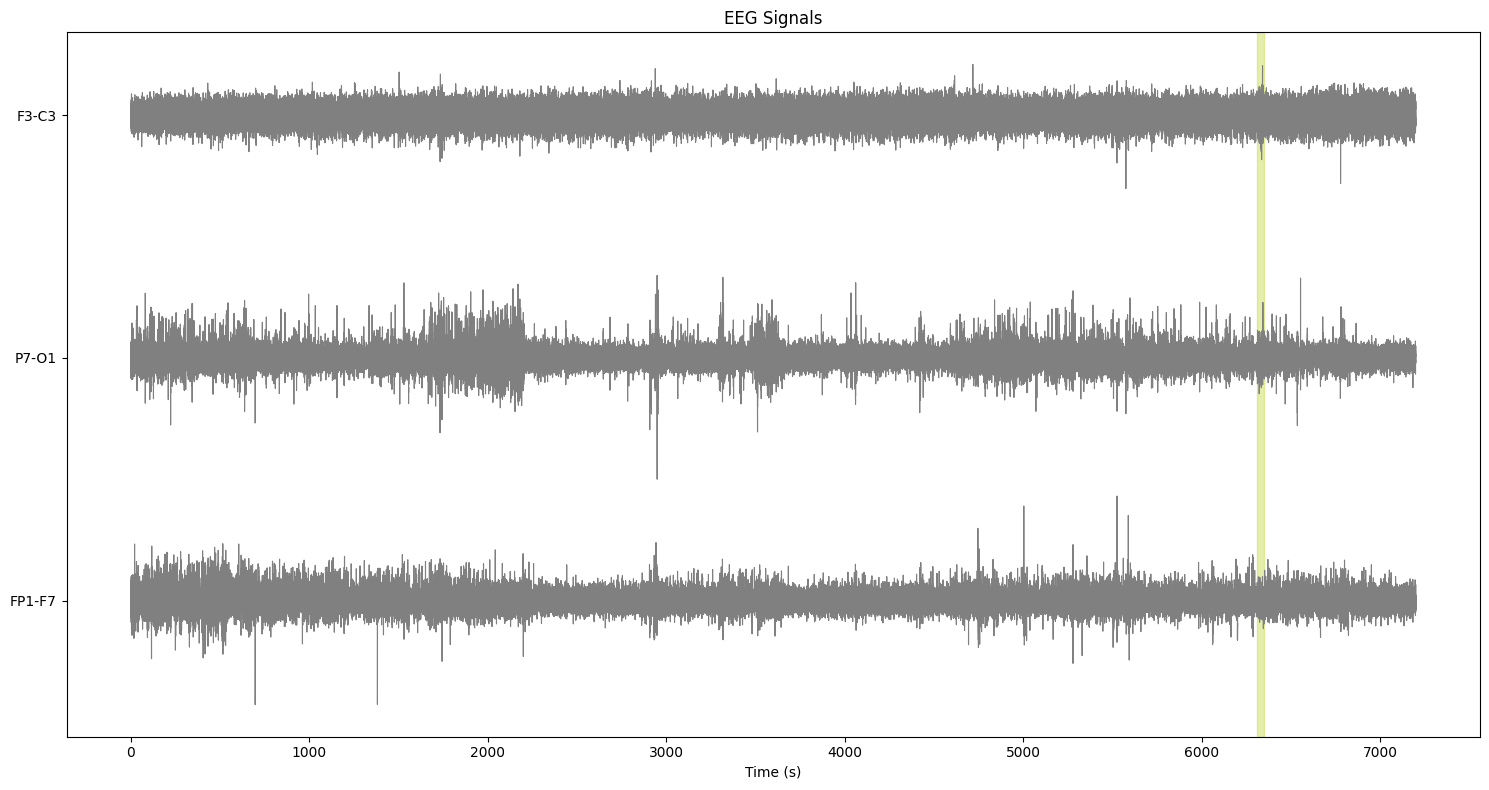

In [10]:
plot_eeg(signals, fs, ch_names, intervals, channels=[0, 3, 5], linewidth=0.8)

## 3.3 Plot Different Time Interval

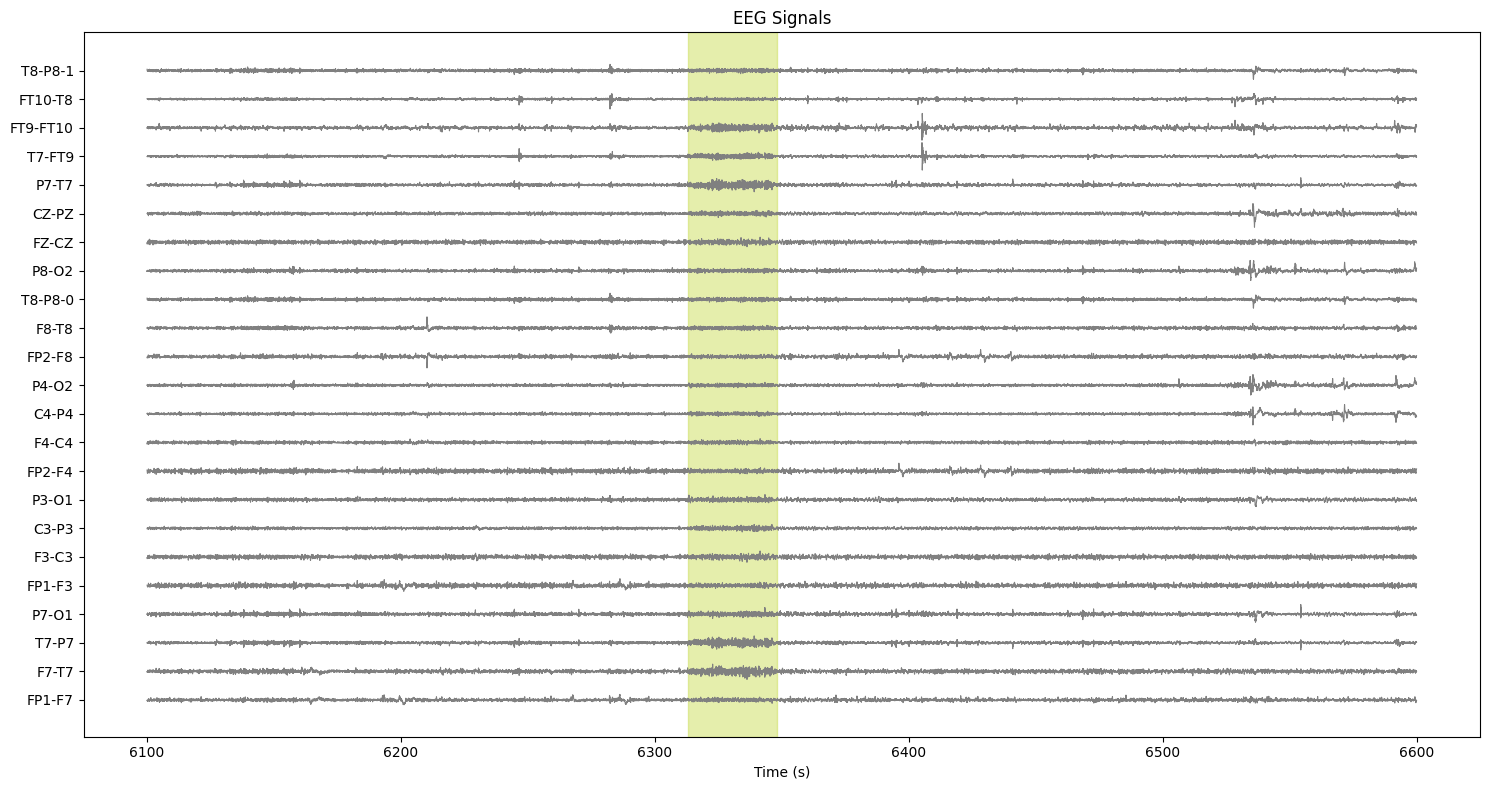

In [9]:
plot_eeg(signals, fs, ch_names, intervals=intervals,t_start= 6100,t_end=6600, linewidth=0.8)

## 3.4 Change Colors

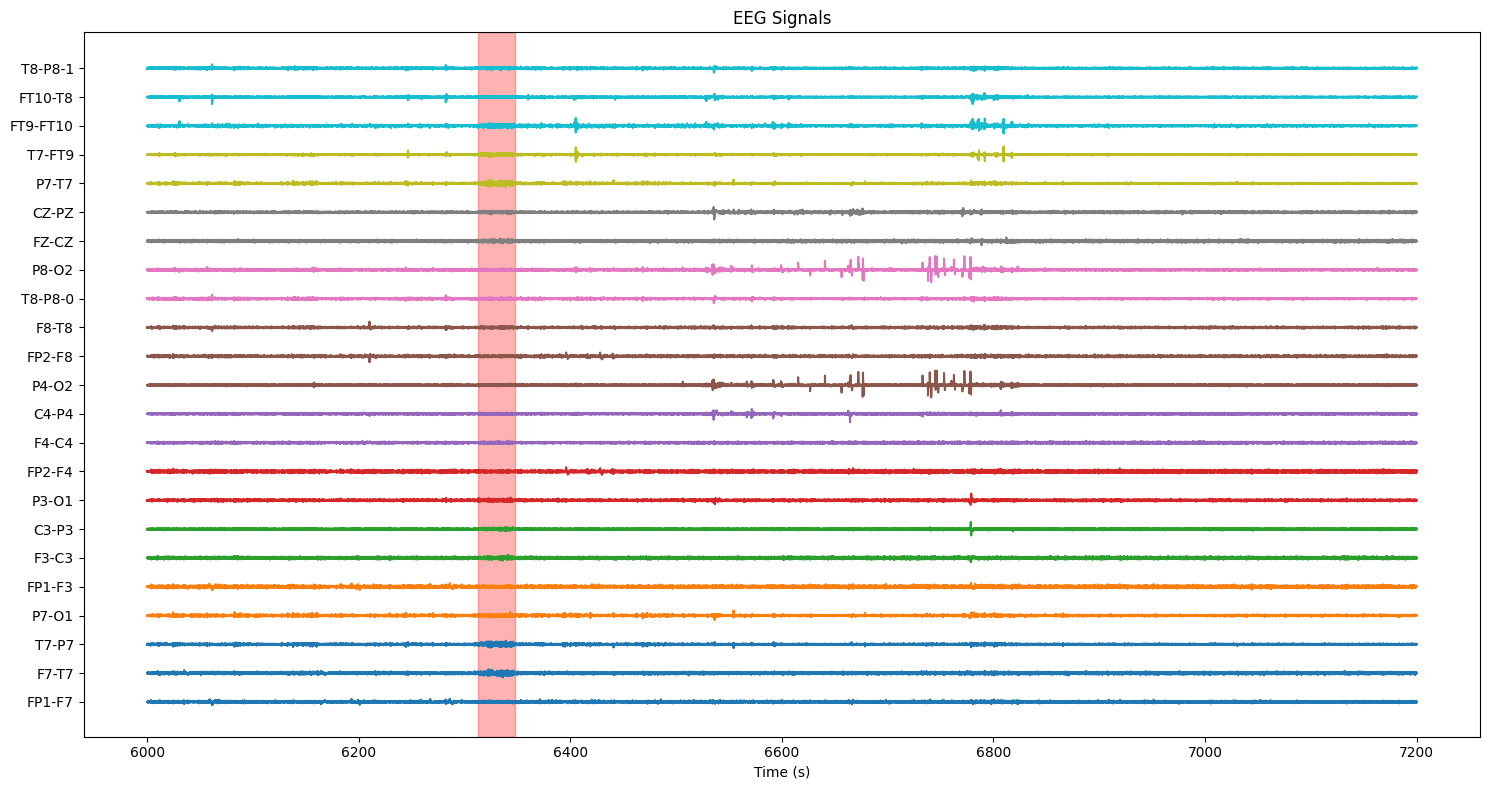

In [36]:
plot_eeg(signals, fs, ch_names, intervals=intervals,t_start= 6000, color_mode='tab10',seizure_color='red', seizure_alpha=0.3)